# kimjaehak_014 · 비용 최적화 정책 비교

`kimjaehak_013`에서 비용 없이 선택한 Expanding 모델과 Fixed 모델의 같은 walk-forward 예측에 비용 기반 의사결정만 추가한다. 모델 성능 개선과 threshold 정책의 효과를 섞지 않고, FP 비용 1에 대한 FN 비용비율을 여러 값으로 바꿔 민감도를 확인한다.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, confusion_matrix, log_loss
from xgboost import XGBClassifier

EXPERIMENT_ID = '0825_kimjaehak_014_cost_optimized_policy'
RANDOM_STATE = 42
DATA_PATH = Path('../data/raw/dataset.csv')
MAPPING_PATH = Path('../data/raw/mapping.json')
TARGET = 'class'
TIME_COLUMN = 'timestamp'
TYPE_COLUMN = 'inspection_type'
RECORD_ID = 'record_id'
ALL_WINDOWS = [f'W{number:02d}' for number in range(1, 11)]
WALK_FORWARD_PAIRS = [('W07', 'W08'), ('W08', 'W09'), ('W09', 'W10')]
MODEL_VARIANTS = ['fixed', 'expanding']
COST_FP = 1
COST_FN_GRID = [10, 25, 50, 100, 200]
MIN_POSITIVES = 20
MIN_NEGATIVES = 100
PROBABILITY_EPSILON = 1e-6

assert DATA_PATH.exists() and MAPPING_PATH.exists()
print('experiment:', EXPERIMENT_ID)
print('cost ratios FP:FN =', [f'1:{value}' for value in COST_FN_GRID])

experiment: 0825_kimjaehak_014_cost_optimized_policy
cost ratios FP:FN = ['1:10', '1:25', '1:50', '1:100', '1:200']


## 1. 데이터와 시간 window

`kimjaehak_013`과 완전히 같은 중복 제거 및 시간 분할을 재현한다.

In [2]:
raw_df = pd.read_csv(DATA_PATH, low_memory=False)
source_index_column = raw_df.columns[0]
if source_index_column.startswith('Unnamed:'):
    raw_df = raw_df.rename(columns={source_index_column: RECORD_ID})
elif source_index_column != RECORD_ID:
    raise ValueError(f'예상하지 못한 첫 번째 컬럼: {source_index_column}')

dedup_columns = [column for column in raw_df.columns if column not in {RECORD_ID, TIME_COLUMN}]
duplicate_mask = raw_df.duplicated(subset=dedup_columns, keep='first')
clean_df = raw_df.loc[~duplicate_mask].copy().reset_index(drop=True)
clean_df[TIME_COLUMN] = pd.to_datetime(clean_df[TIME_COLUMN], errors='raise', utc=True)
clean_df = clean_df.sort_values([TIME_COLUMN, RECORD_ID], kind='stable').reset_index(drop=True)
timestamp_group_sizes = clean_df[TIME_COLUMN].value_counts(sort=False).sort_index()
cumulative_rows = timestamp_group_sizes.cumsum().to_numpy()

def boundary_time(fraction):
    position = int(np.searchsorted(cumulative_rows, len(clean_df) * fraction, side='left'))
    return timestamp_group_sizes.index[position]

window_end_times = pd.DatetimeIndex([boundary_time(fraction) for fraction in np.arange(0.1, 1.01, 0.1)])
window_number = np.searchsorted(
    window_end_times.astype('int64').to_numpy(), clean_df[TIME_COLUMN].astype('int64').to_numpy(), side='left'
)
clean_df['window'] = pd.Categorical(
    [f'W{number + 1:02d}' for number in window_number], categories=ALL_WINDOWS, ordered=True
)
window_data_summary = clean_df.groupby('window', observed=False).agg(
    rows=(TARGET, 'size'), positives=(TARGET, 'sum'), positive_rate=(TARGET, 'mean')
)
assert len(clean_df) == 391_992
assert clean_df.groupby(TIME_COLUMN)['window'].nunique().max() == 1
print(f'clean rows: {len(clean_df):,}, removed duplicates: {int(duplicate_mask.sum()):,}')
display(window_data_summary)

clean rows: 391,992, removed duplicates: 48,282


,rows,positives,positive_rate
window,,,
W01,39210,73,0.001862
W02,39196,712,0.018165
W03,39202,414,0.010561
W04,39192,201,0.005129
W05,39202,277,0.007066
W06,39220,147,0.003748
W07,39180,36,0.000919
W08,39194,327,0.008343
W09,39197,941,0.024007


## 2. 같은 모델에서 calibration 구간과 평가 구간 예측

Expanding은 `kimjaehak_013`의 비용 없는 주 지표로 미리 선택했다. calibration 구간은 모델 학습에서 제외하며, 같은 모델로 직전 구간과 다음 구간의 점수를 모두 만든다.

In [3]:
inspection_types = sorted(clean_df[TYPE_COLUMN].unique().tolist())
with MAPPING_PATH.open(encoding='utf-8') as mapping_file:
    feature_mapping = json.load(mapping_file)
assert set(feature_mapping) == {str(value) for value in inspection_types}
meta_columns = [column for column in clean_df.columns if column.startswith('meta_feat')]
feature_columns_by_type = {
    inspection_type: meta_columns + feature_mapping[str(inspection_type)]
    for inspection_type in inspection_types
}

def training_windows_for(variant, calibration_window):
    calibration_position = ALL_WINDOWS.index(calibration_window)
    if variant == 'fixed':
        return ALL_WINDOWS[:6]
    if variant == 'expanding':
        return ALL_WINDOWS[:calibration_position]
    raise ValueError(variant)

model_cache = {}
score_frames = []

def fit_models(training_windows):
    cache_key = tuple(training_windows)
    if cache_key in model_cache:
        return model_cache[cache_key]
    models = {}
    for inspection_type in inspection_types:
        feature_columns = feature_columns_by_type[inspection_type]
        type_train = clean_df.loc[
            clean_df['window'].isin(training_windows) & (clean_df[TYPE_COLUMN] == inspection_type)
        ]
        model = XGBClassifier(
            random_state=RANDOM_STATE, n_jobs=-1, tree_method='hist',
            objective='binary:logistic', eval_metric=['logloss', 'aucpr'],
        )
        model.fit(type_train[feature_columns], type_train[TARGET].astype('int8'), verbose=False)
        models[inspection_type] = model
    model_cache[cache_key] = models
    return models

for calibration_window, evaluation_window in WALK_FORWARD_PAIRS:
    for variant in MODEL_VARIANTS:
        training_windows = training_windows_for(variant, calibration_window)
        models = fit_models(training_windows)
        for inspection_type in inspection_types:
            feature_columns = feature_columns_by_type[inspection_type]
            for role, window in [('calibration', calibration_window), ('evaluation', evaluation_window)]:
                type_df = clean_df.loc[
                    (clean_df['window'] == window) & (clean_df[TYPE_COLUMN] == inspection_type)
                ]
                probabilities = models[inspection_type].predict_proba(type_df[feature_columns])[:, 1]
                score_frames.append(pd.DataFrame({
                    'variant': variant, 'calibration_window': calibration_window,
                    'evaluation_window': evaluation_window, 'role': role,
                    'inspection_type': inspection_type,
                    'y_true': type_df[TARGET].astype('int8').to_numpy(),
                    'raw_probability': probabilities,
                }))

model_scores = pd.concat(score_frames, ignore_index=True)
print('unique training configurations:', len(model_cache))
print('trained type models:', len(model_cache) * len(inspection_types))

unique training configurations: 3
trained type models: 15


## 3. 비용 정책 정의

- `raw_0.5`: 비용을 사용하지 않는 고정 threshold 비교군
- `raw_empirical_cost`: 직전 구간에서 실제 `FP + FN × 비용비율`이 최소인 type별 raw threshold
- `raw_guarded_cost`: 직전 양성 20개 또는 음성 100개 미만이면 전량 재검사하고, 아니면 empirical threshold 사용
- `platt_analytic_cost`: 직전 구간 Platt calibration 후 이론적 threshold `1 / (1 + FN 비용)` 사용
- `all_manual`: 모든 행을 재검사하는 비용 기준선

모든 threshold와 calibrator는 직전 구간에서만 정하고 다음 구간에 고정 적용한다.

In [4]:
def probability_to_logit(probabilities):
    clipped = np.clip(np.asarray(probabilities, dtype='float64'), PROBABILITY_EPSILON, 1 - PROBABILITY_EPSILON)
    return np.log(clipped / (1 - clipped)).reshape(-1, 1)

def fit_platt_calibrator(probabilities, y_true):
    y_true = np.asarray(y_true, dtype='int8')
    calibrator = LogisticRegression(random_state=RANDOM_STATE, max_iter=2_000, solver='lbfgs')
    calibrator.fit(probability_to_logit(probabilities), y_true)
    calibrator.original_slope_ = float(calibrator.coef_[0, 0])
    calibrator.monotonic_fallback_ = calibrator.original_slope_ < 0
    if calibrator.monotonic_fallback_:
        prevalence = np.clip(y_true.mean(), PROBABILITY_EPSILON, 1 - PROBABILITY_EPSILON)
        calibrator.coef_[0, 0] = 0.0
        calibrator.intercept_[0] = np.log(prevalence / (1 - prevalence))
    return calibrator

def apply_platt(calibrator, probabilities):
    return calibrator.predict_proba(probability_to_logit(probabilities))[:, 1]

def select_empirical_cost_threshold(y_true, probabilities, cost_fn):
    y_true = np.asarray(y_true, dtype='int8')
    probabilities = np.asarray(probabilities, dtype='float64')
    order = np.argsort(-probabilities, kind='stable')
    sorted_y = y_true[order]
    sorted_p = probabilities[order]
    group_ends = np.flatnonzero(np.r_[sorted_p[:-1] != sorted_p[1:], True])
    cumulative_tp = np.cumsum(sorted_y)[group_ends]
    predicted_positive = group_ends + 1
    fp = predicted_positive - cumulative_tp
    fn = int(y_true.sum()) - cumulative_tp
    thresholds = sorted_p[group_ends]
    above_max = np.nextafter(sorted_p[0], np.inf)
    thresholds = np.r_[above_max, thresholds]
    fp = np.r_[0, fp]
    fn = np.r_[int(y_true.sum()), fn]
    costs = fp * COST_FP + fn * cost_fn
    candidates = pd.DataFrame({'threshold': thresholds, 'fp': fp, 'fn': fn, 'cost': costs})
    best = candidates.sort_values(['cost', 'fn', 'fp', 'threshold'], ascending=[True, True, True, False]).iloc[0]
    return float(best['threshold']), int(best['cost'])

def evaluate_policy(y_true, probabilities, threshold, cost_fn):
    y_true = np.asarray(y_true, dtype='int8')
    probabilities = np.asarray(probabilities, dtype='float64')
    predictions = (probabilities >= threshold).astype('int8')
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        'rows': len(y_true), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        'slip_rate': fn / (fn + tp) if (fn + tp) else np.nan,
        'false_call_reduction': tn / (tn + fp) if (tn + fp) else np.nan,
        'recall': tp / (tp + fn) if (tp + fn) else np.nan,
        'total_cost': int(fp * COST_FP + fn * cost_fn),
        'pr_auc': average_precision_score(y_true, probabilities) if len(np.unique(y_true)) > 1 else np.nan,
    }

In [5]:
policy_rows = []
threshold_rows = []
row_policy_frames = []

for calibration_window, evaluation_window in WALK_FORWARD_PAIRS:
    for variant in MODEL_VARIANTS:
        fold_scores = model_scores.loc[
            (model_scores['variant'] == variant)
            & (model_scores['calibration_window'] == calibration_window)
            & (model_scores['evaluation_window'] == evaluation_window)
        ]
        calibration_all = fold_scores.loc[fold_scores['role'] == 'calibration']
        pooled_calibrator = fit_platt_calibrator(calibration_all['raw_probability'], calibration_all['y_true'])
        for inspection_type in inspection_types:
            calibration_rows = calibration_all.loc[calibration_all['inspection_type'] == inspection_type]
            evaluation_rows = fold_scores.loc[
                (fold_scores['role'] == 'evaluation') & (fold_scores['inspection_type'] == inspection_type)
            ]
            positives = int(calibration_rows['y_true'].sum())
            negatives = len(calibration_rows) - positives
            enough_samples = positives >= MIN_POSITIVES and negatives >= MIN_NEGATIVES
            if enough_samples:
                calibrator = fit_platt_calibrator(calibration_rows['raw_probability'], calibration_rows['y_true'])
                calibrator_source = 'type'
            else:
                calibrator = pooled_calibrator
                calibrator_source = 'pooled_fallback'
            calibrated_evaluation = apply_platt(calibrator, evaluation_rows['raw_probability'])

            for cost_fn in COST_FN_GRID:
                empirical_threshold, calibration_cost = select_empirical_cost_threshold(
                    calibration_rows['y_true'], calibration_rows['raw_probability'], cost_fn
                )
                policy_specs = {
                    'raw_0.5': (evaluation_rows['raw_probability'].to_numpy(), 0.5, 'fixed'),
                    'raw_empirical_cost': (evaluation_rows['raw_probability'].to_numpy(), empirical_threshold, 'empirical'),
                    'raw_guarded_cost': (
                        evaluation_rows['raw_probability'].to_numpy(),
                        empirical_threshold if enough_samples else 0.0,
                        'empirical' if enough_samples else 'all_manual_fallback',
                    ),
                    'platt_analytic_cost': (calibrated_evaluation, COST_FP / (COST_FP + cost_fn), calibrator_source),
                    'all_manual': (evaluation_rows['raw_probability'].to_numpy(), 0.0, 'reference'),
                }
                for policy, (probabilities, threshold, source) in policy_specs.items():
                    metrics = evaluate_policy(evaluation_rows['y_true'], probabilities, threshold, cost_fn)
                    policy_rows.append({
                        'evaluation_window': evaluation_window, 'variant': variant,
                        'inspection_type': inspection_type, 'cost_fn': cost_fn,
                        'policy': policy, 'threshold': threshold, 'threshold_source': source,
                        'calibration_positives': positives, 'calibration_negatives': negatives,
                        **metrics,
                    })
                    predictions = (np.asarray(probabilities) >= threshold).astype('int8')
                    row_policy_frames.append(pd.DataFrame({
                        'evaluation_window': evaluation_window, 'variant': variant,
                        'inspection_type': inspection_type, 'cost_fn': cost_fn, 'policy': policy,
                        'y_true': evaluation_rows['y_true'].to_numpy(),
                        'probability': np.asarray(probabilities), 'prediction': predictions,
                    }))
                threshold_rows.append({
                    'evaluation_window': evaluation_window, 'variant': variant,
                    'inspection_type': inspection_type, 'cost_fn': cost_fn,
                    'empirical_threshold': empirical_threshold, 'calibration_cost': calibration_cost,
                    'calibration_positives': positives, 'calibration_negatives': negatives,
                    'enough_samples': enough_samples, 'calibrator_source': calibrator_source,
                    'platt_raw_slope': calibrator.original_slope_,
                    'monotonic_fallback': calibrator.monotonic_fallback_,
                })

type_policy_results = pd.DataFrame(policy_rows)
threshold_history = pd.DataFrame(threshold_rows)
row_policy_predictions = pd.concat(row_policy_frames, ignore_index=True)
display(threshold_history)

,evaluation_window,variant,inspection_type,cost_fn,empirical_threshold,calibration_cost,calibration_positives,calibration_negatives,enough_samples,calibrator_source,platt_raw_slope,monotonic_fallback
0,W08,fixed,0,10,0.574373,10,1,11336,False,pooled_fallback,0.534807,False
1,W08,fixed,0,25,0.574373,25,1,11336,False,pooled_fallback,0.534807,False
2,W08,fixed,0,50,0.574373,50,1,11336,False,pooled_fallback,0.534807,False
3,W08,fixed,0,100,0.574373,100,1,11336,False,pooled_fallback,0.534807,False
4,W08,fixed,0,200,0.574373,200,1,11336,False,pooled_fallback,0.534807,False
...,...,...,...,...,...,...,...,...,...,...,...,...
145,W10,expanding,4,10,0.000680,30,13,35,False,pooled_fallback,0.535633,False
146,W10,expanding,4,25,0.000680,30,13,35,False,pooled_fallback,0.535633,False
147,W10,expanding,4,50,0.000680,30,13,35,False,pooled_fallback,0.535633,False
148,W10,expanding,4,100,0.000680,30,13,35,False,pooled_fallback,0.535633,False


## 4. 다음 구간 비용 결과

비용은 calibration 구간이 아니라 실제 다음 평가 구간에서 집계한다. `savings_vs_raw_0.5`와 `savings_vs_all_manual`이 양수면 해당 기준선보다 비용이 낮다.

In [6]:
def summarize_rows(group, cost_fn):
    y_true = group['y_true'].to_numpy(dtype='int8')
    predictions = group['prediction'].to_numpy(dtype='int8')
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return pd.Series({
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        'slip_rate': fn / (fn + tp) if (fn + tp) else np.nan,
        'false_call_reduction': tn / (tn + fp) if (tn + fp) else np.nan,
        'recall': tp / (tp + fn) if (tp + fn) else np.nan,
        'total_cost': int(fp * COST_FP + fn * cost_fn),
        'pr_auc': average_precision_score(y_true, group['probability']) if len(np.unique(y_true)) > 1 else np.nan,
    })

def summarize_window_rows(group):
    return summarize_rows(group, int(group.name[2]))

def summarize_aggregate_rows(group):
    return summarize_rows(group, int(group.name[1]))

window_policy_summary = (
    row_policy_predictions.groupby(['evaluation_window', 'variant', 'cost_fn', 'policy'], sort=False)
    .apply(summarize_window_rows, include_groups=False)
)
aggregate_policy_summary = (
    row_policy_predictions.groupby(['variant', 'cost_fn', 'policy'], sort=False)
    .apply(summarize_aggregate_rows, include_groups=False)
)

aggregate_table = aggregate_policy_summary.reset_index()
raw_reference = aggregate_table.loc[aggregate_table['policy'] == 'raw_0.5', ['variant', 'cost_fn', 'total_cost']].rename(columns={'total_cost': 'raw_0.5_cost'})
manual_reference = aggregate_table.loc[aggregate_table['policy'] == 'all_manual', ['variant', 'cost_fn', 'total_cost']].rename(columns={'total_cost': 'all_manual_cost'})
aggregate_table = aggregate_table.merge(raw_reference, on=['variant', 'cost_fn']).merge(manual_reference, on=['variant', 'cost_fn'])
aggregate_table['savings_vs_raw_0.5'] = aggregate_table['raw_0.5_cost'] - aggregate_table['total_cost']
aggregate_table['savings_pct_vs_raw_0.5'] = aggregate_table['savings_vs_raw_0.5'] / aggregate_table['raw_0.5_cost'] * 100
aggregate_table['savings_vs_all_manual'] = aggregate_table['all_manual_cost'] - aggregate_table['total_cost']

display(aggregate_table.loc[aggregate_table['cost_fn'] == 100].sort_values(['variant', 'total_cost']))

,variant,cost_fn,policy,tn,fp,fn,tp,slip_rate,false_call_reduction,recall,total_cost,pr_auc,raw_0.5_cost,all_manual_cost,savings_vs_raw_0.5,savings_pct_vs_raw_0.5,savings_vs_all_manual
41,expanding,100,raw_empirical_cost,98387.0,16627.0,530.0,2046.0,0.205745,0.855435,0.794255,69627.0,0.344535,171225.0,115014.0,101598.0,59.335961,45387.0
43,expanding,100,platt_analytic_cost,97267.0,17747.0,640.0,1936.0,0.248447,0.845697,0.751553,81747.0,0.225245,171225.0,115014.0,89478.0,52.257556,33267.0
42,expanding,100,raw_guarded_cost,55670.0,59344.0,377.0,2199.0,0.146351,0.484028,0.853649,97044.0,0.344535,171225.0,115014.0,74181.0,43.323697,17970.0
44,expanding,100,all_manual,0.0,115014.0,0.0,2576.0,0.000000,0.000000,1.000000,115014.0,0.344535,171225.0,115014.0,56211.0,32.828734,0.0
40,expanding,100,raw_0.5,114089.0,925.0,1703.0,873.0,0.661102,0.991958,0.338898,171225.0,0.344535,171225.0,115014.0,0.0,0.000000,-56211.0
18,fixed,100,platt_analytic_cost,92248.0,22766.0,659.0,1917.0,0.255823,0.802059,0.744177,88666.0,0.140155,171946.0,115014.0,83280.0,48.433811,26348.0
16,fixed,100,raw_empirical_cost,94067.0,20947.0,708.0,1868.0,0.274845,0.817874,0.725155,91747.0,0.298083,171946.0,115014.0,80199.0,46.641969,23267.0
19,fixed,100,all_manual,0.0,115014.0,0.0,2576.0,0.000000,0.000000,1.000000,115014.0,0.298083,171946.0,115014.0,56932.0,33.110395,0.0
17,fixed,100,raw_guarded_cost,51745.0,63269.0,562.0,2014.0,0.218168,0.449902,0.781832,119469.0,0.298083,171946.0,115014.0,52477.0,30.519465,-4455.0
15,fixed,100,raw_0.5,113768.0,1246.0,1707.0,869.0,0.662655,0.989167,0.337345,171946.0,0.298083,171946.0,115014.0,0.0,0.000000,-56932.0


In [7]:
cost_policies = ['raw_empirical_cost', 'raw_guarded_cost', 'platt_analytic_cost']
best_policy_by_ratio = (
    aggregate_table.loc[aggregate_table['policy'].isin(cost_policies)]
    .sort_values(['variant', 'cost_fn', 'total_cost', 'fn'])
    .groupby(['variant', 'cost_fn'], as_index=False).first()
)

window_table = window_policy_summary.reset_index()
win_rows = []
for _, row in best_policy_by_ratio.iterrows():
    candidate = window_table.loc[
        (window_table['variant'] == row['variant'])
        & (window_table['cost_fn'] == row['cost_fn'])
        & (window_table['policy'] == row['policy'])
    ].set_index('evaluation_window')
    raw = window_table.loc[
        (window_table['variant'] == row['variant'])
        & (window_table['cost_fn'] == row['cost_fn'])
        & (window_table['policy'] == 'raw_0.5')
    ].set_index('evaluation_window')
    manual = window_table.loc[
        (window_table['variant'] == row['variant'])
        & (window_table['cost_fn'] == row['cost_fn'])
        & (window_table['policy'] == 'all_manual')
    ].set_index('evaluation_window')
    win_rows.append({
        'variant': row['variant'], 'cost_fn': int(row['cost_fn']), 'policy': row['policy'],
        'total_cost': int(row['total_cost']), 'fn': int(row['fn']), 'fp': int(row['fp']),
        'savings_vs_raw_0.5': int(row['savings_vs_raw_0.5']),
        'savings_pct_vs_raw_0.5': row['savings_pct_vs_raw_0.5'],
        'savings_vs_all_manual': int(row['savings_vs_all_manual']),
        'window_wins_vs_raw_0.5': int((candidate['total_cost'] < raw['total_cost']).sum()),
        'window_wins_vs_all_manual': int((candidate['total_cost'] < manual['total_cost']).sum()),
    })
best_policy_summary = pd.DataFrame(win_rows)
display(best_policy_summary)

,variant,cost_fn,policy,total_cost,fn,fp,savings_vs_raw_0.5,savings_pct_vs_raw_0.5,savings_vs_all_manual,window_wins_vs_raw_0.5,window_wins_vs_all_manual
0,expanding,10,platt_analytic_cost,17729,1420,3529,226,1.258702,97285,1,3
1,expanding,25,raw_empirical_cost,29097,857,7672,14403,33.110345,85917,2,3
2,expanding,50,raw_empirical_cost,46200,683,12050,39875,46.325879,68814,3,3
3,expanding,100,raw_empirical_cost,69627,530,16627,101598,59.335961,45387,3,3
4,expanding,200,platt_analytic_cost,108172,406,26972,233353,68.326770,6842,3,1
5,fixed,10,platt_analytic_cost,22404,1562,6784,-4088,-22.319284,92610,0,3
6,fixed,25,platt_analytic_cost,38741,1065,12116,5180,11.793903,76273,3,3
7,fixed,50,raw_empirical_cost,54835,772,16235,31761,36.677214,60179,3,3
8,fixed,100,platt_analytic_cost,88666,659,22766,83280,48.433811,26348,3,2
9,fixed,200,platt_analytic_cost,129623,499,29823,213023,62.169995,-14609,3,1


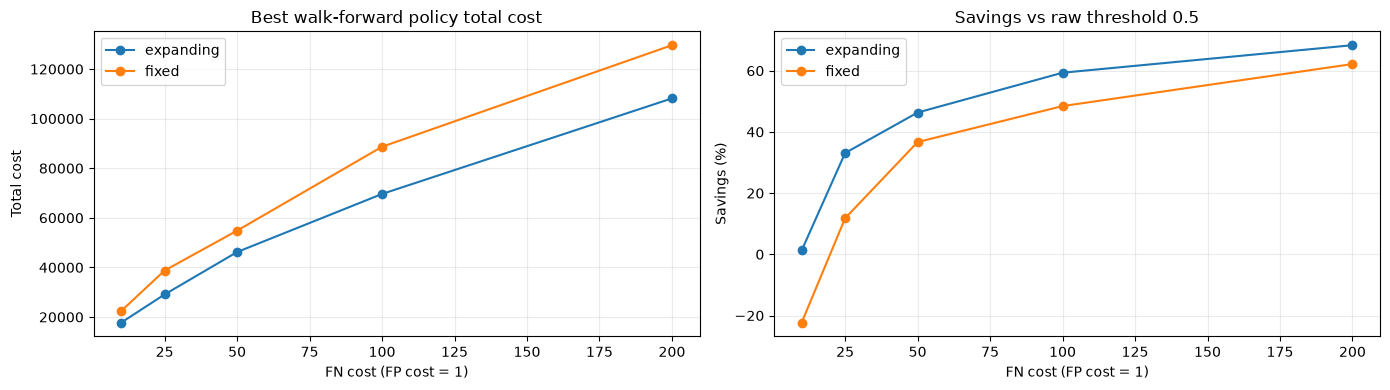

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for variant, group in best_policy_summary.groupby('variant'):
    axes[0].plot(group['cost_fn'], group['total_cost'], marker='o', label=variant)
    axes[1].plot(group['cost_fn'], group['savings_pct_vs_raw_0.5'], marker='o', label=variant)
axes[0].set_title('Best walk-forward policy total cost')
axes[0].set_xlabel('FN cost (FP cost = 1)')
axes[0].set_ylabel('Total cost')
axes[1].set_title('Savings vs raw threshold 0.5')
axes[1].set_xlabel('FN cost (FP cost = 1)')
axes[1].set_ylabel('Savings (%)')
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend()
plt.tight_layout()
plt.show()

In [9]:
ratio_100 = best_policy_summary.loc[best_policy_summary['cost_fn'] == 100].set_index('variant')
fixed_100 = ratio_100.loc['fixed']
expanding_100 = ratio_100.loc['expanding']
fallback_count = int((threshold_history['enough_samples'] == False).sum() / len(COST_FN_GRID))
negative_slope_count = int(threshold_history.loc[threshold_history['cost_fn'] == 100, 'monotonic_fallback'].sum())

conclusion = f'''
### 실행 결과

FP:FN 비용비율 1:100에서 사전 정의한 정책들 가운데 다음 구간의 사후 관측 총비용이 가장 낮았던 정책은 다음과 같습니다. 이 비교 자체로 운영 정책이 미리 선택됐다는 뜻은 아닙니다.

- Fixed: **{fixed_100['policy']}**, 비용 **{int(fixed_100['total_cost']):,}**, raw 0.5 대비 **{fixed_100['savings_pct_vs_raw_0.5']:.2f}%** 절감, 구간 승리 **{int(fixed_100['window_wins_vs_raw_0.5'])}/3**
- Expanding: **{expanding_100['policy']}**, 비용 **{int(expanding_100['total_cost']):,}**, raw 0.5 대비 **{expanding_100['savings_pct_vs_raw_0.5']:.2f}%** 절감, 구간 승리 **{int(expanding_100['window_wins_vs_raw_0.5'])}/3**
- 5개 비용비율 전체의 상세 결과는 `best_policy_summary`에 기록했습니다.
- type별 empirical threshold를 보수적으로 대체한 희소 type×fold는 모델 variant당이 아니라 전체 **{fallback_count}개 조합**이며, 1:100에서 음수 Platt slope fallback은 **{negative_slope_count}회**였습니다.

### 판정

비용 최적화의 이득은 raw 0.5 및 전량 재검사 기준선과 다음 구간에서 비교해야 합니다. 특정 비용비율에서만 이득이 나거나 3개 구간 중 일부에서만 이기면 운영 확정이 아니라 비용 가정에 민감한 후보입니다. 실제 현장 FP·FN 비용이 정해지기 전에는 하나의 정책을 최종 채택하지 않습니다.
'''
display(Markdown(conclusion))


### 실행 결과

FP:FN 비용비율 1:100에서 사전 정의한 정책들 가운데 다음 구간의 사후 관측 총비용이 가장 낮았던 정책은 다음과 같습니다. 이 비교 자체로 운영 정책이 미리 선택됐다는 뜻은 아닙니다.

- Fixed: **platt_analytic_cost**, 비용 **88,666**, raw 0.5 대비 **48.43%** 절감, 구간 승리 **3/3**
- Expanding: **raw_empirical_cost**, 비용 **69,627**, raw 0.5 대비 **59.34%** 절감, 구간 승리 **3/3**
- 5개 비용비율 전체의 상세 결과는 `best_policy_summary`에 기록했습니다.
- type별 empirical threshold를 보수적으로 대체한 희소 type×fold는 모델 variant당이 아니라 전체 **12개 조합**이며, 1:100에서 음수 Platt slope fallback은 **2회**였습니다.

### 판정

비용 최적화의 이득은 raw 0.5 및 전량 재검사 기준선과 다음 구간에서 비교해야 합니다. 특정 비용비율에서만 이득이 나거나 3개 구간 중 일부에서만 이기면 운영 확정이 아니라 비용 가정에 민감한 후보입니다. 실제 현장 FP·FN 비용이 정해지기 전에는 하나의 정책을 최종 채택하지 않습니다.
